# Supplement 1: Nonlinear curve fitting

In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings('ignore')

In [2]:
adata = sc.read_h5ad(r'spatial_sixtime_slice_stereoseq.h5ad')
adata.obsm['spatial'] = np.array(adata.obs.loc[:,['spatial_x', 'spatial_y']])
adata = adata[adata.obs['time']=='24hpf']

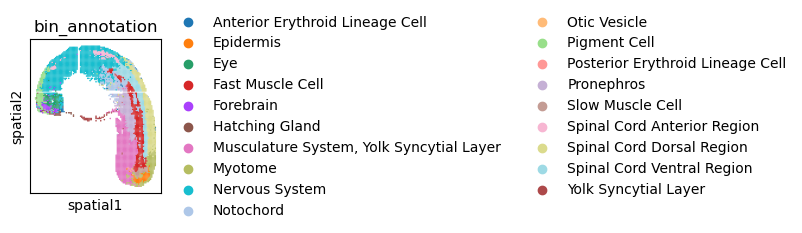

In [3]:
fig, ax = plt.subplots(figsize=(1.7, 2))

sc.pl.embedding(
    adata,
    basis='spatial',
    color='bin_annotation',
    s=5,
    ax=ax,
    show=True
)

#fig.savefig("bin_annotation.svg", bbox_inches="tight")
plt.close(fig)

In [4]:
spatial = adata.obs.loc[:,['spatial_x', 'spatial_y']]

In [5]:
def parametric_curve(t, *coefficients):
    """
    Parametric curve: x = f(t), y = g(t)
    Use two polynomials to fit x and y separately
    """
    degree = len(coefficients) // 2
    coeffs_x = coefficients[:degree+1]
    coeffs_y = coefficients[degree+1:]
    
    # Construct the polynomial
    x_fit = np.polyval(coeffs_x, t)
    y_fit = np.polyval(coeffs_y, t)
    
    return np.column_stack([x_fit, y_fit])

In [6]:
x = spatial['spatial_x'].values
y = spatial['spatial_y'].values
points = np.column_stack([x, y])

# Compute the angle from each point to the centroid as parameter t
centroid = [10000, 500]
angles = np.arctan2(points[:, 1] - centroid[1], points[:, 0] - centroid[0])

# Sort the angles to obtain a continuous parameter t
sort_idx = np.argsort(angles)
t_normalized = np.linspace(0, 1, len(points))

In [7]:
degree = 5  # Polynomial degree

# Fit x(t)
coeffs_x = np.polyfit(t_normalized, x[sort_idx], degree)
# Fit y(t) 
coeffs_y = np.polyfit(t_normalized, y[sort_idx], degree)

# Generate a smooth fitted curve
t_smooth = np.linspace(0, 1, 200)
x_smooth = np.polyval(coeffs_x, t_smooth)
y_smooth = np.polyval(coeffs_y, t_smooth)

In [8]:
from scipy.spatial.distance import cdist
def distance_to_curve(points, curve_points):
    """Compute the minimum distance from each point to the curve points"""
    distances = cdist(points, curve_points)
    return np.min(distances, axis=1)
distance_threshold = 500
degree = 5
x = spatial['spatial_x'].values
y = spatial['spatial_y'].values
points = np.column_stack([x, y])
ct = [10000,500]


# First fit
centroid = ct
angles = np.arctan2(points[:, 1] - centroid[1], points[:, 0] - centroid[0])
sort_idx = np.argsort(angles)
t_normalized = np.linspace(0, 1, len(points))

coeffs_x = np.polyfit(t_normalized, x[sort_idx], degree)
coeffs_y = np.polyfit(t_normalized, y[sort_idx], degree)

# Generate the fitted curve
t_curve = np.linspace(0, 1, 200)
x_curve = np.polyval(coeffs_x, t_curve)
y_curve = np.polyval(coeffs_y, t_curve)
curve_points = np.column_stack([x_curve, y_curve])

# Compute the distance from each point to the curve
distances = distance_to_curve(points, curve_points)

# Keep points with distances below the threshold
keep_mask = distances <= distance_threshold
filtered_x = x[keep_mask]
filtered_y = y[keep_mask]

# Refit using the filtered points
filtered_points = np.column_stack([filtered_x, filtered_y])
centroid_final = ct
angles_final = np.arctan2(filtered_points[:, 1] - centroid_final[1], 
                         filtered_points[:, 0] - centroid_final[0])
sort_idx_final = np.argsort(angles_final)
t_normalized_final = np.linspace(0, 1, len(filtered_points))

coeffs_x_final = np.polyfit(t_normalized_final, filtered_x[sort_idx_final], degree)
coeffs_y_final = np.polyfit(t_normalized_final, filtered_y[sort_idx_final], degree)

# Generate the final smooth curve
t_smooth = np.linspace(0, 1, 500)
x_smooth = np.polyval(coeffs_x_final, t_smooth)
y_smooth = np.polyval(coeffs_y_final, t_smooth)
final_curve = np.column_stack([x_smooth, y_smooth])


In [9]:
points = np.column_stack([x, y])

In [10]:
def find_closest_t_for_points(points, curve_points, t_curve):
    """
    Find the t value corresponding to the nearest point on the curve for each point.

    Parameters:
    points: Cell point coordinate array (n, 2)
    curve_points: Curve point coordinate array (m, 2)
    t_curve: Array of parameter t values corresponding to the curve points (m,)

    Returns:
    closest_t: t value of the nearest curve point for each point (n,)
    closest_distances: Minimum distance from each point to the curve (n,)
    closest_curve_points: Coordinates of the nearest curve point for each point (n, 2)
    """
    # Compute the distance matrix from each point to the curve points
    distances = cdist(points, curve_points)
    
    # Find the index of the nearest curve point for each point
    closest_indices = np.argmin(distances, axis=1)
    
    # Get the corresponding t values
    closest_t = t_curve[closest_indices]
    
    # Get the nearest distances
    closest_distances = np.min(distances, axis=1)
    
    # Get the coordinates of the nearest curve points
    closest_curve_points = curve_points[closest_indices]
    
    return closest_t, closest_distances, closest_curve_points

In [11]:
closest_t_all, distances_all, curve_points_all = find_closest_t_for_points(
    points, final_curve, t_smooth
)

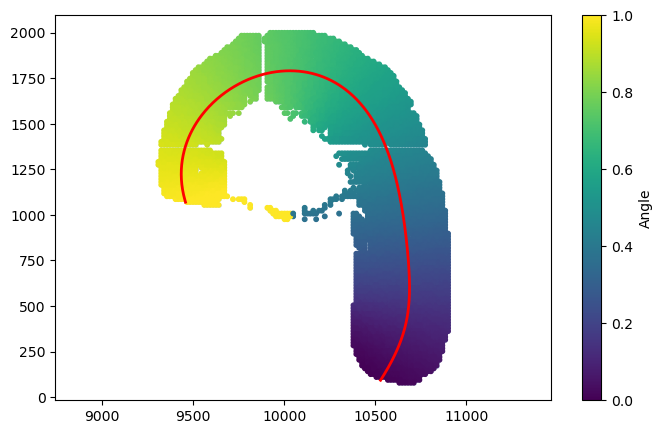

In [12]:
plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.3, s=5)
scatter = plt.scatter(x, y, 
                     c=closest_t_all, cmap='viridis', s=10)
plt.colorbar(scatter, label='Angle')


plt.plot(x_smooth, y_smooth, 'r-', linewidth=2)
#plt.xlabel('spatial_x')
#plt.ylabel('spatial_y')
#plt.title('Parametric Curve Fitting for Ring-Shaped Data')
#plt.legend()
#plt.grid(True, alpha=0.3)
plt.axis('equal')  # Keep the aspect ratio equal
plt.savefig('Theta.png', dpi=600)
plt.show()
